In [1]:
# Lê Đăng Ninh - B22DCCN%72

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# 1. Sinh tập dữ liệu
def generate_data(num_users=500, num_records=5000):
    user_ids = [f"U{str(i).zfill(3)}" for i in range(1, num_users + 1)]
    product_ids = [f"P{str(i).zfill(3)}" for i in range(1, 101)] # 100 sản phẩm
    actions = ['view', 'click', 'add_to_cart']
    # Trọng số hành vi (view nhiều nhất, add_to_cart ít nhất)
    action_weights = [0.6, 0.3, 0.1] 
    
    start_time = datetime(2024, 1, 1)
    
    data = []
    for _ in range(num_records):
        user = random.choice(user_ids)
        product = random.choice(product_ids)
        action = random.choices(actions, weights=action_weights)[0]
        # Sinh thời gian ngẫu nhiên
        time_offset = timedelta(days=random.randint(0, 90), minutes=random.randint(0, 1440))
        timestamp = start_time + time_offset
        
        data.append([user, product, action, timestamp])
        
    df = pd.DataFrame(data, columns=['user_id', 'product_id', 'action', 'timestamp'])
    df = df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)
    return df

df = generate_data()
df.to_csv('data_user500.csv', index=False)
print("Đã tạo file data_user500.csv thành công!")
df.head(20)

Đã tạo file data_user500.csv thành công!


,user_id,product_id,action,timestamp
0,U001,P074,view,2024-01-01 10:35:00
1,U001,P078,click,2024-01-14 15:44:00
2,U001,P088,click,2024-01-29 14:46:00
3,U001,P059,click,2024-02-05 20:06:00
4,U001,P031,add_to_cart,2024-02-06 10:47:00
5,U001,P038,view,2024-02-14 06:47:00
6,U001,P019,view,2024-03-18 04:46:00
7,U001,P035,click,2024-03-18 18:14:00
8,U001,P071,view,2024-03-23 18:27:00
9,U002,P048,click,2024-01-02 16:28:00


Training RNN...
Training LSTM...
Training BiLSTM...


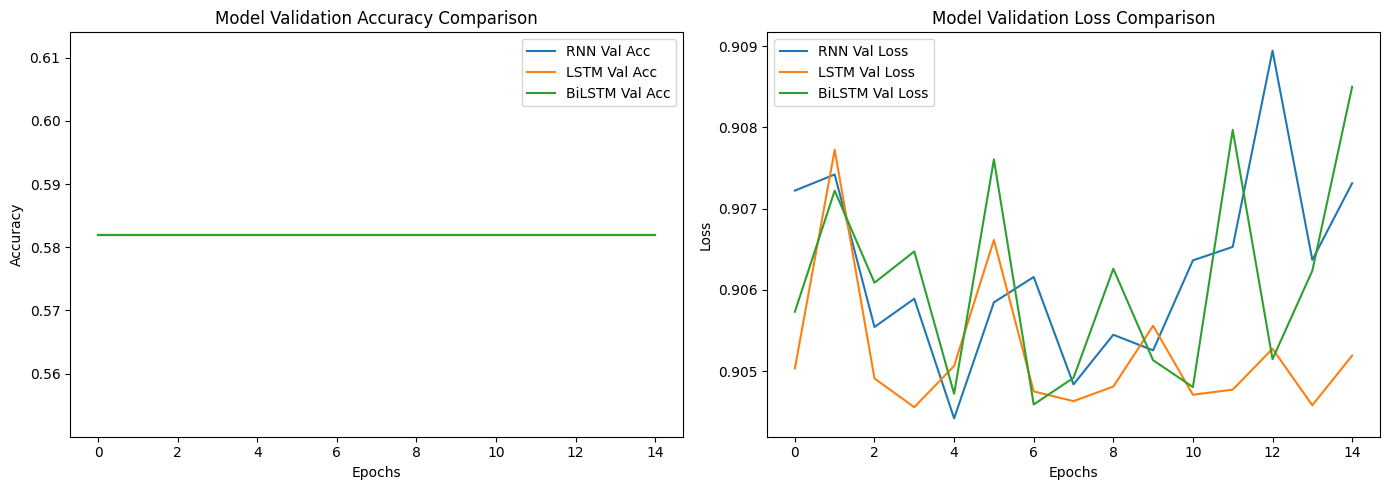

In [2]:
# Lê Đăng Ninh - B22DCCN572

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Bidirectional, Dense, Embedding
import matplotlib.pyplot as plt

# 1. Tiền xử lý dữ liệu (Tạo sequences)
df = pd.read_csv('data_user500.csv')
le_action = LabelEncoder()
df['action_encoded'] = le_action.fit_transform(df['action']) # 0, 1, 2

# Nhóm theo user để tạo chuỗi thời gian
SEQ_LENGTH = 3
X, y = [], []

for user, group in df.groupby('user_id'):
    actions = group['action_encoded'].values
    if len(actions) > SEQ_LENGTH:
        for i in range(len(actions) - SEQ_LENGTH):
            X.append(actions[i:i+SEQ_LENGTH])
            y.append(actions[i+SEQ_LENGTH])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Định nghĩa 3 mô hình
vocab_size = len(le_action.classes_)

def build_rnn():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=16, input_length=SEQ_LENGTH),
        SimpleRNN(32),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_lstm():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=16, input_length=SEQ_LENGTH),
        LSTM(32),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_bilstm():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=16, input_length=SEQ_LENGTH),
        Bidirectional(LSTM(32)),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# 3. Training
epochs = 15
models = {'RNN': build_rnn(), 'LSTM': build_lstm(), 'BiLSTM': build_bilstm()}
histories = {}

for name, model in models.items():
    print(f"Training {name}...")
    histories[name] = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), verbose=0)

# 4. Visualization (Plots kết quả)
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=f'{name} Val Acc')
plt.title('Model Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
for name, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=f'{name} Val Loss')
plt.title('Model Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN...

--- Training RNN Model ---
Epoch 1/50
88/88 [==============================] - 4s 13ms/step - loss: 0.9423 - accuracy: 0.5844 - val_loss: 0.9079 - val_accuracy: 0.5820 - lr: 0.0010
Epoch 2/50
88/88 [==============================] - 1s 11ms/step - loss: 0.9144 - accuracy: 0.5866 - val_loss: 0.9084 - val_accuracy: 0.5820 - lr: 0.0010
Epoch 3/50
88/88 [==============================] - 1s 10ms/step - loss: 0.9125 - accuracy: 0.5905 - val_loss: 0.9070 - val_accuracy: 0.5820 - lr: 0.0010
Epoch 4/50
88/88 [==============================] - 1s 12ms/step - loss: 0.9085 - accuracy: 0.5898 - val_loss: 0.9076 - val_accuracy: 0.5820 - lr: 0.0010
Epoch 5/50
88/88 [==============================] - 1s 7ms/step - loss: 0.9095 - accuracy: 0.5898 - val_loss: 0.9072 - val_accuracy: 0.5820 - lr: 0.0010
Epoch 6/50
79/88 [=========================>....] - ETA: 0s - loss: 0.9005 - accuracy: 0.5918
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8

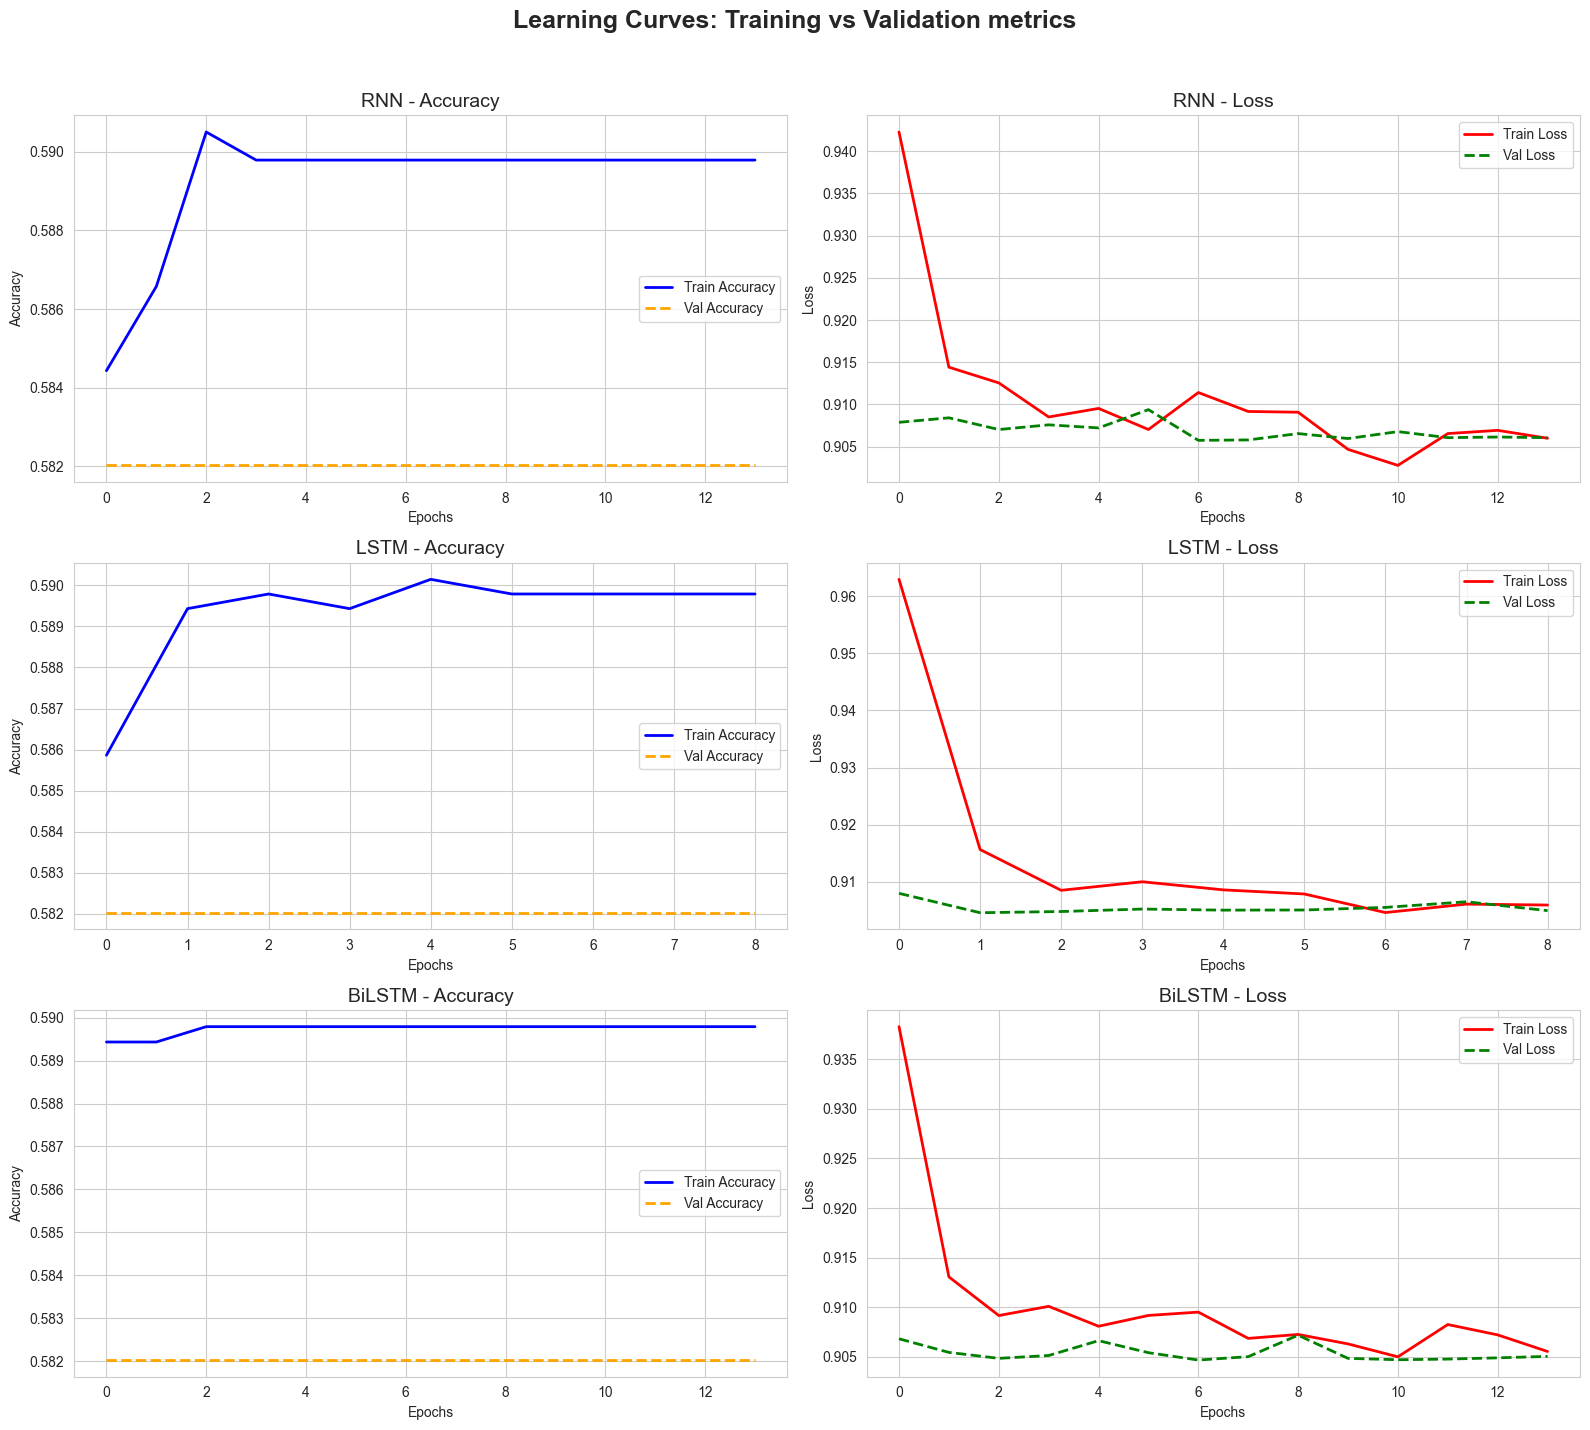

C:\Users\Admin\AppData\Local\Temp\ipykernel_38052\788389835.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=accuracies, ax=ax[0], palette="viridis")
C:\Users\Admin\AppData\Local\Temp\ipykernel_38052\788389835.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=losses, ax=ax[1], palette="magma")


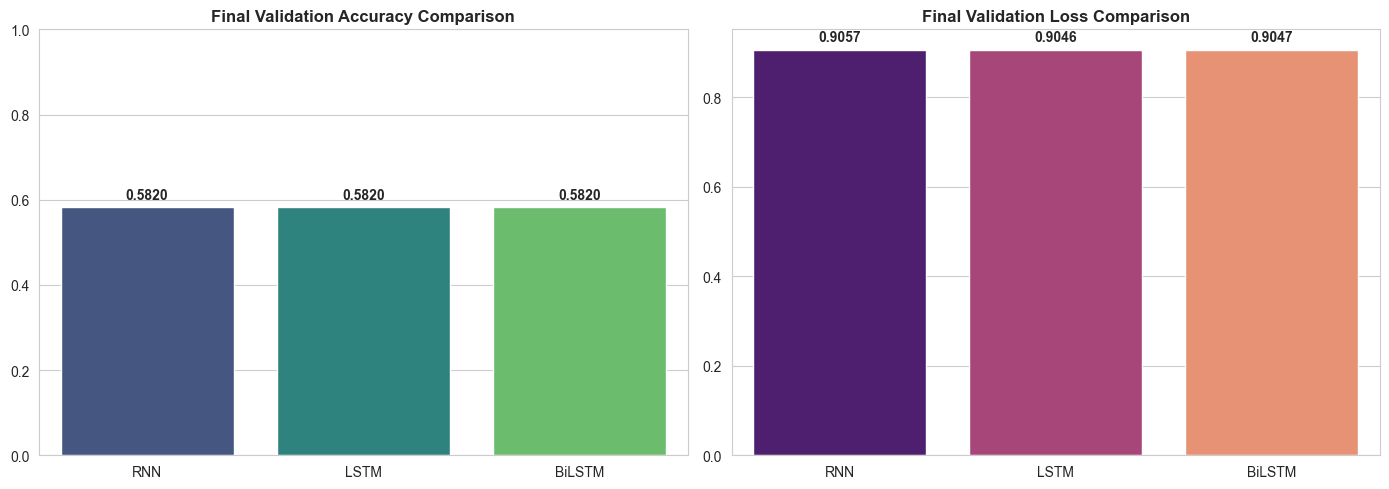


ĐÁNH GIÁ CHI TIẾT MÔ HÌNH BEST (BiLSTM)
22/22 [==============================] - 2s 3ms/step

Classification Report:

              precision    recall  f1-score   support

 add_to_cart       0.00      0.00      0.00        67
       click       0.00      0.00      0.00       226
        view       0.58      1.00      0.74       408

    accuracy                           0.58       701
   macro avg       0.19      0.33      0.25       701
weighted avg       0.34      0.58      0.43       701



C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

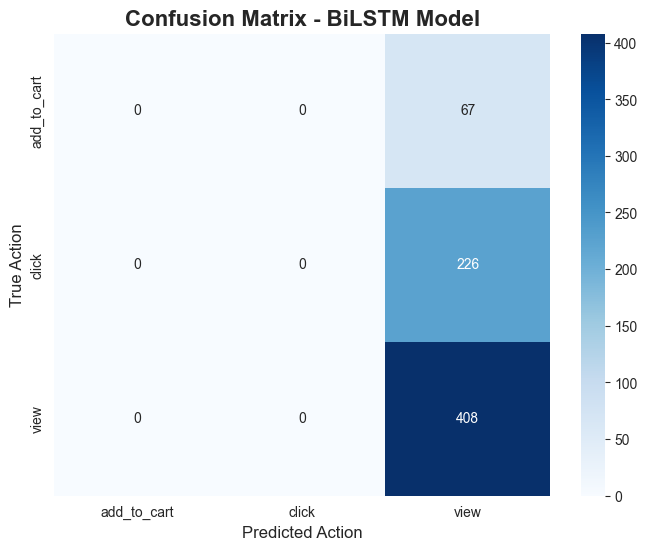

In [3]:
# Lê Đăng Ninh - B22DCCN572

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Bidirectional, Dense, Embedding, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. TIỀN XỬ LÝ DỮ LIỆU
# ---------------------------------------------------------
df = pd.read_csv('data_user500.csv')
le_action = LabelEncoder()
df['action_encoded'] = le_action.fit_transform(df['action']) # 0, 1, 2

# Ánh xạ ngược để dùng cho vẽ biểu đồ sau này
action_labels = le_action.classes_ 

SEQ_LENGTH = 3
X, y = [], []

for user, group in df.groupby('user_id'):
    actions = group['action_encoded'].values
    if len(actions) > SEQ_LENGTH:
        for i in range(len(actions) - SEQ_LENGTH):
            X.append(actions[i:i+SEQ_LENGTH])
            y.append(actions[i+SEQ_LENGTH])

X = np.array(X)
y = np.array(y)

# Chia tập train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 2. ĐỊNH NGHĨA KIẾN TRÚC MÔ HÌNH (NÂNG CAO)
# ---------------------------------------------------------
vocab_size = len(action_labels)
EMBEDDING_DIM = 32 # Tăng số chiều không gian vector

def build_rnn():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=SEQ_LENGTH),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.3), # Chống overfitting
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_lstm():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=SEQ_LENGTH),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_bilstm():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=SEQ_LENGTH),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# ---------------------------------------------------------
# 3. QUÁ TRÌNH TRAINING VỚI CALLBACKS
# ---------------------------------------------------------
# Cài đặt số lượng Epochs lớn, dùng Callbacks để quản lý việc dừng sớm
EPOCHS = 50
BATCH_SIZE = 32

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

models = {'RNN': build_rnn(), 'LSTM': build_lstm(), 'BiLSTM': build_bilstm()}
histories = {}
eval_results = {}

print("BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN...")
for name, model in models.items():
    print(f"\n--- Training {name} Model ---")
    histories[name] = model.fit(
        X_train, y_train, 
        epochs=EPOCHS, 
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test), 
        callbacks=callbacks,
        verbose=1 # Đổi thành 1 để theo dõi quá trình train
    )
    # Lưu lại kết quả đánh giá cuối cùng
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    eval_results[name] = {'Loss': loss, 'Accuracy': acc}

# ---------------------------------------------------------
# 4. VISUALIZATION CHUYÊN SÂU
# ---------------------------------------------------------
sns.set_style("whitegrid")

# --- Plot 1: Quá trình hội tụ (Accuracy & Loss cho từng model) ---
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Learning Curves: Training vs Validation metrics', fontsize=18, fontweight='bold')

for i, (name, hist) in enumerate(histories.items()):
    # Cột 1: Accuracy
    axes[i, 0].plot(hist.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
    axes[i, 0].plot(hist.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2, linestyle='--')
    axes[i, 0].set_title(f'{name} - Accuracy', fontsize=14)
    axes[i, 0].set_xlabel('Epochs')
    axes[i, 0].set_ylabel('Accuracy')
    axes[i, 0].legend()

    # Cột 2: Loss
    axes[i, 1].plot(hist.history['loss'], label='Train Loss', color='red', linewidth=2)
    axes[i, 1].plot(hist.history['val_loss'], label='Val Loss', color='green', linewidth=2, linestyle='--')
    axes[i, 1].set_title(f'{name} - Loss', fontsize=14)
    axes[i, 1].set_xlabel('Epochs')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# --- Plot 2: So sánh hiệu năng tổng thể của 3 mô hình ---
names = list(eval_results.keys())
accuracies = [eval_results[n]['Accuracy'] for n in names]
losses = [eval_results[n]['Loss'] for n in names]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart Accuracy
sns.barplot(x=names, y=accuracies, ax=ax[0], palette="viridis")
ax[0].set_title('Final Validation Accuracy Comparison', fontweight='bold')
ax[0].set_ylim(0, 1)
for i, v in enumerate(accuracies):
    ax[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

# Bar chart Loss
sns.barplot(x=names, y=losses, ax=ax[1], palette="magma")
ax[1].set_title('Final Validation Loss Comparison', fontweight='bold')
for i, v in enumerate(losses):
    ax[1].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Plot 3: Đánh giá chi tiết mô hình tốt nhất (Giả sử là BiLSTM) ---
print("\nĐÁNH GIÁ CHI TIẾT MÔ HÌNH BEST (BiLSTM)")
best_model = models['BiLSTM']
y_pred_probs = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# In báo cáo phân loại (Precision, Recall, F1-score)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes, target_names=action_labels))

# Vẽ Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=action_labels, yticklabels=action_labels)
plt.title('Confusion Matrix - BiLSTM Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Action', fontsize=12)
plt.ylabel('True Action', fontsize=12)
plt.show()

In [5]:
!pip install neo4j pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Lê Đăng Ninh - B22DCCN572
# Cài đặt: pip install neo4j pandas
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687" # Đổi thành URI của bạn
AUTH = ("neo4j", "12345678")  # Đổi password của bạn

# 1. Khởi tạo driver
driver = GraphDatabase.driver(URI, auth=AUTH)

# 2. Đọc dữ liệu
df = pd.read_csv('data_user500.csv')

# 3. Hàm tạo node và relationship
def create_graph(tx, user_id, product_id, action, timestamp):
    # Chuẩn hóa tên Relationship theo chuẩn Neo4j (viết hoa, cách nhau bởi gạch dưới)
    if action == 'view':
        rel_type = "VIEWED"
    elif action == 'click':
        rel_type = "CLICKED"
    else:
        rel_type = "ADDED_TO_CART"
        
    # Dùng f-string để chèn linh hoạt rel_type
    # Dùng MERGE để nếu bạn lỡ chạy lại cell Jupyter nhiều lần thì không bị duplicate data
    query = f"""
    MERGE (u:User {{id: $user_id}})
    MERGE (p:Product {{id: $product_id}})
    MERGE (u)-[:{rel_type} {{time: $timestamp}}]->(p)
    """
    
    tx.run(query, user_id=user_id, product_id=product_id, timestamp=str(timestamp))

# 4. Thực thi transaction
print("Đang đẩy dữ liệu lên Neo4j, vui lòng chờ...")
with driver.session() as session:
    for index, row in df.iterrows():
        # Dùng execute_write thay cho write_transaction (chuẩn mới)
        session.execute_write(create_graph, row['user_id'], row['product_id'], row['action'], row['timestamp'])

# 5. Đóng kết nối để giải phóng bộ nhớ
driver.close()
print("Đã xây dựng xong Knowledge Graph!")

Đang đẩy dữ liệu lên Neo4j, vui lòng chờ...
Đã xây dựng xong Knowledge Graph!


In [7]:
MATCH p=(u:User)-[r:ADDED_TO_CART|CLICKED]->(prod:Product)
RETURN p
LIMIT 50

SyntaxError: invalid syntax (2061757729.py, line 1)

In [8]:
!pip install fastapi uvicorn nest-asyncio pydantic langchain langchain-openai langchain-community neo4j

  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 6.4 MB/s  0:00:00
   ---------------------------------------- 0.0/879.4 kB ? eta -:--:--
   ---------------------------------------- 879.4/879.4 kB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------ --------------- 1.6/2.5 MB 7.0 MB/s eta 0:00:01
   ------------------------------------- -- 2.4/2.5 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 5.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 7.1 MB/s  0:00:00
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------------ --------------- 1.3/2.1 MB 7.4 MB/s eta 0:00:01
   ------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.
scipy 1.12.0 requires numpy<1.29.0,>=1.22.4, but you have numpy 2.4.4 which is incompatible.
tensorflow-intel 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 2.4.4 which is incompatible.
tensorflow-i

In [10]:
!pip install "numpy<=1.24.3" "typing-extensions<4.6.0"

  Using cached numpy-1.24.3-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
  Using cached typing_extensions-4.5.0-py3-none-any.whl.metadata (8.5 kB)
Using cached numpy-1.24.3-cp311-cp311-win_amd64.whl (14.8 MB)
Using cached typing_extensions-4.5.0-py3-none-any.whl (27 kB)

  Attempting uninstall: typing-extensions

    Found existing installation: typing_extensions 4.15.0

    Uninstalling typing_extensions-4.15.0:

   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastapi 0.121.3 requires typing-extensions>=4.8.0, but you have typing-extensions 4.5.0 which is incompatible.
ipython 9.4.0 requires typing_extensions>=4.6; python_version < "3.12", but you have typing-extensions 4.5.0 which is incompatible.
langchain-community 0.4.1 requires numpy>=1.26.2; python_version < "3.13", but you have numpy 1.24.3 which is incompatible.
langchain-core 1.3.0 requires typing-extensions<5.0.0,>=4.7.0, but you have typing-extensions 4.5.0 which is incompatible.
openai 2.32.0 requires typing-extensions<5,>=4.11, but you have typing-extensions 4.5.0 which is incompatible.
openai 2.32.0 requires typing-extensions<5,>=4.14, but you have typing-extensions 4.5.0 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.24.3 whic

In [ ]:
# Lê Đăng Ninh - B22DCCN572

import nest_asyncio
import uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import os
from langchain.chains import GraphCypherQAChain
from langchain_community.graphs import Neo4jGraph
from langchain_openai import ChatOpenAI

# KÍCH HOẠT NEST_ASYNCIO CHO JUPYTER NOTEBOOK
nest_asyncio.apply()

# 1. Cấu hình Key

# 2. Kết nối Knowledge Graph
graph = Neo4jGraph(
    url="neo4j://127.0.0.1:7687", 
    username="neo4j", 
    password="12345678"
)
graph.refresh_schema()

# 3. Khởi tạo GraphRAG Pipeline
llm = ChatOpenAI(temperature=0, model="gpt-4o-mini")
chain = GraphCypherQAChain.from_llm(
    cypher_llm=llm, qa_llm=llm, graph=graph, verbose=True, allow_dangerous_requests=True
)

# 4. Khởi tạo API Server
app = FastAPI(title="E-Commerce GraphRAG API")

# Cấp quyền CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class ChatRequest(BaseModel):
    user_id: str
    message: str

@app.post("/api/chat")
async def chat_with_bot(req: ChatRequest):
    personalized_query = f"Tôi là người dùng {req.user_id}. {req.message}"
    try:
        response = chain.invoke({"query": personalized_query})
        return {"status": "success", "reply": response['result']}
    except Exception as e:
        return {"status": "error", "reply": "Xin lỗi, hệ thống tư vấn đang bận. Vui lòng thử lại sau!", "details": str(e)}

# 5. Khởi động Server
if __name__ == "__main__":
    print("🚀 API Server đang chạy tại: http://localhost:8000")
    print("⏳ Chú ý: Cell này sẽ chạy liên tục để duy trì server.")
    print("⏹️ Để tắt server, hãy bấm nút Stop (hình vuông) trên thanh công cụ Jupyter.")
    
    # Chạy uvicorn trực tiếp
    uvicorn.run(app, host="0.0.0.0", port=8000)

In [2]:
!pip install langchain langchain-community langchain-openai


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Lê Đăng Ninh - B22DCCN572

import nest_asyncio
import uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import os
from langchain.chains import GraphCypherQAChain
from langchain_community.graphs import Neo4jGraph
from langchain_openai import ChatOpenAI

# KÍCH HOẠT NEST_ASYNCIO CHO JUPYTER NOTEBOOK
nest_asyncio.apply()

# 1. Cấu hình Key


# 2. Kết nối Knowledge Graph
graph = Neo4jGraph(
    url="neo4j://127.0.0.1:7687", 
    username="neo4j", 
    password="12345678"
)
graph.refresh_schema()

# 3. Khởi tạo GraphRAG Pipeline
llm = ChatOpenAI(temperature=0, model="gpt-4o-mini")
chain = GraphCypherQAChain.from_llm(
    cypher_llm=llm, qa_llm=llm, graph=graph, verbose=True, allow_dangerous_requests=True
)

# 4. Khởi tạo API Server
app = FastAPI(title="E-Commerce GraphRAG API")

# Cấp quyền CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class ChatRequest(BaseModel):
    user_id: str
    message: str

@app.post("/api/chat")
async def chat_with_bot(req: ChatRequest):
    personalized_query = f"Tôi là người dùng {req.user_id}. {req.message}"
    try:
        response = chain.invoke({"query": personalized_query})
        return {"status": "success", "reply": response['result']}
    except Exception as e:
        return {"status": "error", "reply": "Xin lỗi, hệ thống tư vấn đang bận. Vui lòng thử lại sau!", "details": str(e)}

# 5. Khởi động Server
if __name__ == "__main__":
    print("🚀 API Server đang chạy tại: http://localhost:8000")
    print("⏳ Chú ý: Cell này sẽ chạy liên tục để duy trì server.")
    print("⏹️ Để tắt server, hãy bấm nút Stop (hình vuông) trên thanh công cụ Jupyter.")
    
    # Chạy uvicorn trực tiếp
    uvicorn.run(app, host="0.0.0.0", port=8000)

ModuleNotFoundError: No module named 'langchain.chains'

In [2]:
!pip install langchain


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip --version

pip 25.2 from C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip (python 3.11)



In [4]:
import sys
print(sys.executable)

C:\Users\Admin\AppData\Local\Programs\Python\Python311\python.exe


In [5]:
import sys
!{sys.executable} -m pip install --force-reinstall langchain langchain-community langchain-openai

  Using cached langchain-1.2.15-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_openai-1.1.15-py3-none-any.whl.metadata (3.1 kB)
  Using cached langchain_core-1.3.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached langgraph-1.1.9-py3-none-any.whl.metadata (8.0 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langsmith-0.7.33-py3-none-any.whl.metadata (15 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached uuid_utils-0.14.1-cp39-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached langgraph_checkpoint-4.0.2-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.0.10-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.3.13-py3-none-any.whl.metadata (1.6 kB)
  Using cached xxhash-3.6.0-cp311-cp311-win_amd64.whl.metadata (13 kB)
 

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
gradio 6.0.0 requires pydantic<=2.12.4,>=2.11.10, but you have pydantic 2.13.3 which is incompatible.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.
scipy 1.12.0 requires numpy<1.29.0,>=1.22.4, but you have numpy 2.4.4

In [ ]:
# Lê Đăng Ninh - B22DCCN572

import nest_asyncio
import uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import os
from langchain.chains import GraphCypherQAChain
from langchain_community.graphs import Neo4jGraph
from langchain_openai import ChatOpenAI

# KÍCH HOẠT NEST_ASYNCIO CHO JUPYTER NOTEBOOK
nest_asyncio.apply()

# 1. Cấu hình Key


# 2. Kết nối Knowledge Graph
graph = Neo4jGraph(
    url="neo4j://127.0.0.1:7687", 
    username="neo4j", 
    password="12345678"
)
graph.refresh_schema()

# 3. Khởi tạo GraphRAG Pipeline
llm = ChatOpenAI(temperature=0, model="gpt-4o-mini")
chain = GraphCypherQAChain.from_llm(
    cypher_llm=llm, qa_llm=llm, graph=graph, verbose=True, allow_dangerous_requests=True
)

# 4. Khởi tạo API Server
app = FastAPI(title="E-Commerce GraphRAG API")

# Cấp quyền CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class ChatRequest(BaseModel):
    user_id: str
    message: str

@app.post("/api/chat")
async def chat_with_bot(req: ChatRequest):
    personalized_query = f"Tôi là người dùng {req.user_id}. {req.message}"
    try:
        response = chain.invoke({"query": personalized_query})
        return {"status": "success", "reply": response['result']}
    except Exception as e:
        return {"status": "error", "reply": "Xin lỗi, hệ thống tư vấn đang bận. Vui lòng thử lại sau!", "details": str(e)}

# 5. Khởi động Server
if __name__ == "__main__":
    print("🚀 API Server đang chạy tại: http://localhost:8000")
    print("⏳ Chú ý: Cell này sẽ chạy liên tục để duy trì server.")
    print("⏹️ Để tắt server, hãy bấm nút Stop (hình vuông) trên thanh công cụ Jupyter.")
    
    # Chạy uvicorn trực tiếp
    uvicorn.run(app, host="0.0.0.0", port=8000)

ModuleNotFoundError: No module named 'langchain.chains'

In [2]:
!pip install langchain-neo4j

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 1.8/36.6 MB 9.1 MB/s eta 0:00:04
   ---- ----------------------------------- 3.7/36.6 MB 9.1 MB/s eta 0:00:04
   ----- ---------------------------------- 5.2/36.6 MB 8.6 MB/s eta 0:00:04
   ------- -------------------------------- 7.1/36.6 MB 8.4 MB/s eta 0:00:04
   --------- ------------------------------ 8.7/36.6 MB 8.1 MB/s eta 0:00:04
   ----------- ---------------------------- 10.5/36.6 MB 8.2 MB/s eta 0:00:04
   ------------- -------------------------- 12.3/36.6 MB 8.2 MB/s eta 0:00:03
   --------------- ------------------------ 13.9/36.6 MB 8.1 MB/s eta 0:00:03
   ----------------- ---------------------- 15.7/36.6 MB 8.1 MB/s eta 0:00:03
   ------------------ --------------------- 17.3/36.6 MB 8.0 MB/s eta 0:00:03
   -------------------- ------------------- 19.1/36.6 MB 8.1 MB/s eta 0:00:03
   ---------------------- ----------------- 21.0/36.6 MB 8.2 MB/s eta 0:00:02

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
gradio 6.0.0 requires pydantic<=2.12.4,>=2.11.10, but you have pydantic 2.13.3 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Lê Đăng Ninh - B22DCCN572

import nest_asyncio
import uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import os

# ---> ĐÃ SỬA CODE: Dùng chuẩn mới nhất của LangChain cho Neo4j <---
from langchain_neo4j import Neo4jGraph, GraphCypherQAChain
from langchain_openai import ChatOpenAI

# KÍCH HOẠT NEST_ASYNCIO CHO JUPYTER NOTEBOOK
nest_asyncio.apply()

# 1. Cấu hình Key (NHỚ ĐIỀN KEY MỚI VÀO ĐÂY, KHÔNG DÙNG KEY CŨ BỊ LỘ)


# 2. Kết nối Knowledge Graph
graph = Neo4jGraph(
    url="bolt://127.0.0.1:7687", 
    username="neo4j", 
    password="12345678"
)
graph.refresh_schema()

# 3. Khởi tạo GraphRAG Pipeline
llm = ChatOpenAI(temperature=0, model="gpt-4o-mini")
chain = GraphCypherQAChain.from_llm(
    cypher_llm=llm, qa_llm=llm, graph=graph, verbose=True, allow_dangerous_requests=True
)

# 4. Khởi tạo API Server
app = FastAPI(title="E-Commerce GraphRAG API")

# Cấp quyền CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class ChatRequest(BaseModel):
    user_id: str
    message: str

@app.post("/api/chat")
async def chat_with_bot(req: ChatRequest):
    personalized_query = f"Tôi là người dùng {req.user_id}. {req.message}"
    try:
        response = chain.invoke({"query": personalized_query})
        return {"status": "success", "reply": response['result']}
    except Exception as e:
        return {"status": "error", "reply": "Xin lỗi, hệ thống tư vấn đang bận. Vui lòng thử lại sau!", "details": str(e)}

# 5. Khởi động Server
if __name__ == "__main__":
    print("🚀 API Server đang chạy tại: http://localhost:8000")
    print("⏳ Chú ý: Cell này sẽ chạy liên tục để duy trì server.")
    print("⏹️ Để tắt server, hãy bấm nút Stop (hình vuông) trên thanh công cụ Jupyter.")
    
    # Chạy uvicorn trực tiếp
    uvicorn.run(app, host="0.0.0.0", port=8000)

🚀 API Server đang chạy tại: http://localhost:8000
⏳ Chú ý: Cell này sẽ chạy liên tục để duy trì server.
⏹️ Để tắt server, hãy bấm nút Stop (hình vuông) trên thanh công cụ Jupyter.


RuntimeError: Cannot run the event loop while another loop is running

In [ ]:
# Lê Đăng Ninh - B22DCCN572

import nest_asyncio
import uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import os

from langchain_neo4j import Neo4jGraph, GraphCypherQAChain
from langchain_openai import ChatOpenAI

# KÍCH HOẠT NEST_ASYNCIO CHO JUPYTER NOTEBOOK
nest_asyncio.apply()

# 1. Cấu hình Key (ĐIỀN KEY MỚI VÀO ĐÂY)
 

# 2. Kết nối Knowledge Graph
graph = Neo4jGraph(
    url="bolt://127.0.0.1:7687", 
    username="neo4j", 
    password="12345678"
)
graph.refresh_schema()

# 3. Khởi tạo GraphRAG Pipeline
llm = ChatOpenAI(temperature=0, model="gpt-4o-mini")
chain = GraphCypherQAChain.from_llm(
    cypher_llm=llm, qa_llm=llm, graph=graph, verbose=True, allow_dangerous_requests=True
)

# 4. Khởi tạo API Server
app = FastAPI(title="E-Commerce GraphRAG API")

# Cấp quyền CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class ChatRequest(BaseModel):
    user_id: str
    message: str

@app.post("/api/chat")
async def chat_with_bot(req: ChatRequest):
    personalized_query = f"Tôi là người dùng {req.user_id}. {req.message}"
    try:
        response = chain.invoke({"query": personalized_query})
        return {"status": "success", "reply": response['result']}
    except Exception as e:
        return {"status": "error", "reply": "Xin lỗi, hệ thống tư vấn đang bận. Vui lòng thử lại sau!", "details": str(e)}

# 5. Khởi động Server (Cách chuẩn cho Jupyter Notebook)
config = uvicorn.Config(app, host="0.0.0.0", port=8000)
server = uvicorn.Server(config)

print("🚀 API Server đang chạy tại: http://localhost:8000")
print("⏳ Chú ý: Cell này sẽ chạy liên tục để duy trì server.")
print("⏹️ Để tắt server, hãy bấm nút Stop (hình vuông) trên thanh công cụ Jupyter.")

# Dùng await thay vì uvicorn.run()
await server.serve()

INFO:     Started server process [86360]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


🚀 API Server đang chạy tại: http://localhost:8000
⏳ Chú ý: Cell này sẽ chạy liên tục để duy trì server.
⏹️ Để tắt server, hãy bấm nút Stop (hình vuông) trên thanh công cụ Jupyter.
